In [ ]:
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 19.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# importing Libraries
import pandas as pd
import spacy
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/Hate Speech.zip')

In [ ]:
df.shape

(24783, 7)

In [ ]:
df.head()

,Unnamed: 0,count,hate_speech,offensive_language,neither,class,tweet
0,0,3,0,0,3,2,!!! RT @mayasolovely: As a woman you shouldn't...
1,1,3,0,3,0,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...
2,2,3,0,3,0,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...
3,3,3,0,2,1,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...
4,4,6,0,6,0,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...


In [ ]:
# deleting unwanted columns
df.drop(columns = ['Unnamed: 0', 'count','hate_speech', 'offensive_language','neither'],inplace=True)

In [ ]:
#checking null values
df.isna().sum()

,0
class,0
tweet,0


In [ ]:
df['tweet'].iloc[0]

"!!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out..."

In [ ]:
df['tweet'].iloc[100]

'"@ClicquotSuave: LMAOOOOOOOOOOO this nigga @Krillz_Nuh_Care http://t.co/AAnpSUjmYI" &lt;bitch want likes for some depressing shit..foh'

In [ ]:
df['tweet'].iloc[1000]

'&#128514;&#128514;&#128514;&#128514;&#128514;&#128514;&#128514;"@betysweetcocker: That pussy is just....&#128561; imma assume she just had a baby like..the day before"'

In [ ]:
# deleting unwanted symbols
df['processed_tweet']=df['tweet'].str.replace('[^a-zA-Z]','',regex=True)

In [ ]:
df.head()

,class,tweet,processed_tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RTmayasolovelyAsawomanyoushouldntcomplainabout...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RTCGAndersonvivabasedshelooklikeatranny
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RTShenikaRobertsTheshityouhearaboutmemightbetr...


In [ ]:
df['processed_tweet'].iloc[1000]

'betysweetcockerThatpussyisjustimmaassumeshejusthadababylikethedaybefore'

In [ ]:
#handling unwanted spaces
df['processes_tweet_2']=df['processed_tweet'].str.replace(r'[\s]+','',regex=True)

In [ ]:
df.head()

,class,tweet,processed_tweet,processes_tweet_2
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RTmayasolovelyAsawomanyoushouldntcomplainabout...,RTmayasolovelyAsawomanyoushouldntcomplainabout...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RTCGAndersonvivabasedshelooklikeatranny,RTCGAndersonvivabasedshelooklikeatranny
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RTShenikaRobertsTheshityouhearaboutmemightbetr...,RTShenikaRobertsTheshityouhearaboutmemightbetr...


In [ ]:
#NLP
nlp=spacy.load('en_core_web_sm')

In [ ]:
#lemmatization
def lemmatization(text):
    doc = nlp(text)
    lemmaList = [word.lemma_ for word in doc]
    return ' '.join(lemmaList)

In [ ]:
df['lemma_tweet'] = df['processes_tweet_2'].apply(lemmatization)

In [ ]:
df.head()

,class,tweet,processed_tweet,processes_tweet_2,lemma_tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RTmayasolovelyAsawomanyoushouldntcomplainabout...,RTmayasolovelyAsawomanyoushouldntcomplainabout...,rtmayasolovelyasawomanyoushouldntcomplainabout...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...,rturkindofbranddawgrtsbabylifeyoueverfuckabitc...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RTCGAndersonvivabasedshelooklikeatranny,RTCGAndersonvivabasedshelooklikeatranny,RTCGAndersonvivabasedshelooklikeatranny
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RTShenikaRobertsTheshityouhearaboutmemightbetr...,RTShenikaRobertsTheshityouhearaboutmemightbetr...,RTShenikaRobertsTheshityouhearaboutmemightbetr...


In [ ]:
df['processes_tweet_2'].iloc[67]

'AllyhaaaaaLemmieeataOreoampdothesedishesOneoreoLol'

In [ ]:
df['lemma_tweet'].iloc[67]

'allyhaaaaalemmieeataoreoampdothesedishesoneoreolol'

In [ ]:
#removing the stopwords
def remove_stopwords(text):
  doc = nlp(text)
  no_stopwords_list = [word.text for word in doc if not word.is_stop]
  return ' '.join(no_stopwords_list)



In [ ]:
df['final_tweet'] = df['lemma_tweet'].apply(remove_stopwords)

In [ ]:
df['lemma_tweet'].iloc[67]

'allyhaaaaalemmieeataoreoampdothesedishesoneoreolol'

In [ ]:
df['final_tweet'].iloc[67]

'allyhaaaaalemmieeataoreoampdothesedishesoneoreolol'

In [ ]:
df.head()

,class,tweet,processed_tweet,processes_tweet_2,lemma_tweet,final_tweet
0,2,!!! RT @mayasolovely: As a woman you shouldn't...,RTmayasolovelyAsawomanyoushouldntcomplainabout...,RTmayasolovelyAsawomanyoushouldntcomplainabout...,rtmayasolovelyasawomanyoushouldntcomplainabout...,rtmayasolovelyasawomanyoushouldntcomplainabout...
1,1,!!!!! RT @mleew17: boy dats cold...tyga dwn ba...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...,RTmleewboydatscoldtygadwnbadforcuffindathoeint...
2,1,!!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...,RTUrKindOfBrandDawgRTsbabylifeYoueverfuckabitc...,rturkindofbranddawgrtsbabylifeyoueverfuckabitc...,rturkindofbranddawgrtsbabylifeyoueverfuckabitc...
3,1,!!!!!!!!! RT @C_G_Anderson: @viva_based she lo...,RTCGAndersonvivabasedshelooklikeatranny,RTCGAndersonvivabasedshelooklikeatranny,RTCGAndersonvivabasedshelooklikeatranny,RTCGAndersonvivabasedshelooklikeatranny
4,1,!!!!!!!!!!!!! RT @ShenikaRoberts: The shit you...,RTShenikaRobertsTheshityouhearaboutmemightbetr...,RTShenikaRobertsTheshityouhearaboutmemightbetr...,RTShenikaRobertsTheshityouhearaboutmemightbetr...,RTShenikaRobertsTheshityouhearaboutmemightbetr...


In [ ]:
# One-Hot Representation
vocab_size = 10000
one_hot_representation = [one_hot(words, vocab_size) for words in df['final_tweet']]

In [ ]:
df['final_tweet'].iloc[0]

'rtmayasolovelyasawomanyoushouldntcomplainaboutcleaningupyourhouseampasamanyoushouldalwaystakethetrashout'

In [ ]:
one_hot_representation[100]

[2422]

In [ ]:

one_hot_representation[0]

[3778]

In [ ]:
for i in range(0,4):
  print(df['final_tweet'].iloc[i])

rtmayasolovelyasawomanyoushouldntcomplainaboutcleaningupyourhouseampasamanyoushouldalwaystakethetrashout
RTmleewboydatscoldtygadwnbadforcuffindathoeinthestplace
rturkindofbranddawgrtsbabylifeyoueverfuckabitchandshestarttocryyoubeconfusedasshit
RTCGAndersonvivabasedshelooklikeatranny


In [ ]:
for i in range(0,4):
  print(one_hot_representation[i])

[3778]
[4475]
[5900]
[788]


In [ ]:
sentence_length=20
embedded_tweet = pad_sequences(one_hot_representation, padding='pre', maxlen = sentence_length)

In [ ]:
for i in range(0,4):
  print(embedded_tweet[i])

[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0 3778]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0 4475]
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0 5900]
[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0 788]


In [ ]:
x=np.array(embedded_tweet)
y=np.array(df['class'])

In [ ]:
df['class'].value_counts()

,count
class,
1,19190
2,4163
0,1430


In [ ]:
smote = SMOTE(sampling_strategy='minority')
x,y = smote.fit_resample(x,y)

In [ ]:
#Train-Test Split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((34034, 20), (8509, 20), (34034,), (8509,))

In [ ]:
#creating Model
dimension = 50
model = keras.Sequential([
    #embeddig layer
    keras.layers.Embedding(vocab_size,dimension,input_length=sentence_length),
    #LSTM Layers(stacked)
    keras.layers.LSTM(100,return_sequences=True),
    keras.layers.LSTM(50, return_sequences=True),
    keras.layers.LSTM(50, return_sequences=True),
    keras.layers.LSTM(50),
    #output layer
    keras.layers.Dense(3, activation = 'softmax')
])
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(x_train, y_train, epochs=20, batch_size=32)

Epoch 1/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 64s 61ms/step - accuracy: 0.7017 - loss: 0.6049
Epoch 2/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.7031 - loss: 0.5836
Epoch 3/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.7044 - loss: 0.5782
Epoch 4/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 80s 57ms/step - accuracy: 0.7064 - loss: 0.5716
Epoch 5/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 59s 56ms/step - accuracy: 0.7053 - loss: 0.5702
Epoch 6/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 65s 61ms/step - accuracy: 0.7034 - loss: 0.5684
Epoch 7/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 78s 58ms/step - accuracy: 0.7024 - loss: 0.5721
Epoch 8/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 63s 60ms/step - accuracy: 0.7086 - loss: 0.5673
Epoch 9/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 61s 57ms/step - accuracy: 0.7053 - loss: 0.5660
Epoch 10/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 61s 57ms/step - accuracy: 0.7102 - loss: 0.5619
Epoch 11/20
1064/1064 ━━━━━━━━━━━━━━━━━━━━ 61s 57ms/step - accuracy: 0.7102 - loss: 0.5626
Epoch 12

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5270 - loss: 2.1000
Model Accuracy: 52.78%


In [ ]:
pred = np.argmax(model.predict(x_test),axis=-1)


266/266 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step



In [ ]:
y_test[:5]

array([1, 1, 0, 1, 2])

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.54      0.71      0.61      3812
           1       0.54      0.48      0.51      3807
           2       0.16      0.03      0.04       890

    accuracy                           0.54      8509
   macro avg       0.41      0.41      0.39      8509
weighted avg       0.50      0.54      0.51      8509



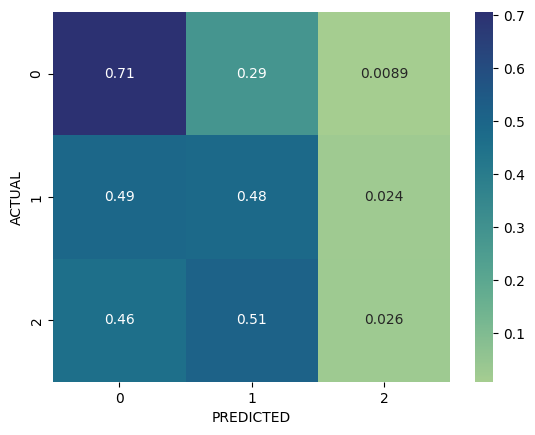

In [ ]:
cf = confusion_matrix(y_test,pred,normalize = 'true')
sns.heatmap(cf, annot = True, cmap='crest');
plt.xlabel('PREDICTED');
plt.ylabel('ACTUAL');